Dataset Shape: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
After Feature Engineering: (20640, 11)

Linear Regression
RMSE: 0.6958701266963986
R2 Score: 0.6304701499538703

Ridge Regression
Best Alpha: {'alpha': 10}
RMSE: 0.6959195832838997
R2 Score: 0.6304176219487071

Decision Tree Regressor
Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
RMSE: 0.6290075326248504
R2 Score: 0.6980709971707264

Model Comparison
               Model      RMSE  R2 Score
0  Linear Regressio

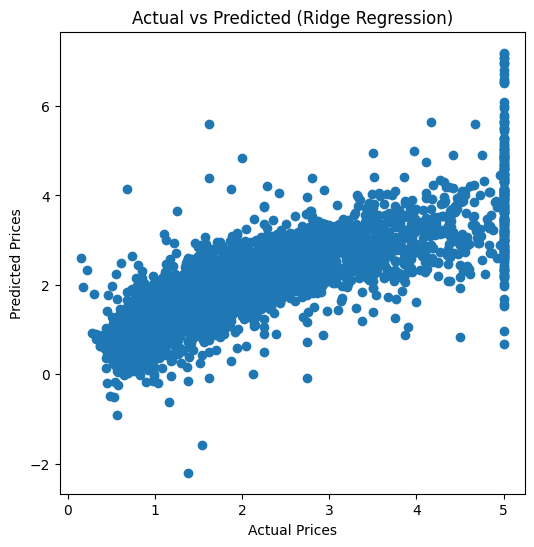

In [1]:
# ==========================================
# TASK 2: Feature Engineering & Model Comparison
# ==========================================

# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset
# ==========================================

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dataset Shape:", X.shape)
print(X.head())

# ==========================================
# 3. Feature Engineering
# ==========================================

# Creating new meaningful features
X["Rooms_per_Household"] = X["AveRooms"] / X["HouseAge"]
X["Bedrooms_per_Room"] = X["AveBedrms"] / X["AveRooms"]
X["Population_per_Household"] = X["Population"] / X["AveOccup"]

# Handle infinite values (if any)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

print("After Feature Engineering:", X.shape)

# ==========================================
# 4. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 6. Model 1 – Linear Regression
# ==========================================

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression")
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

# ==========================================
# 7. Model 2 – Ridge Regression (Optimization)
# ==========================================

ridge = Ridge()

param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(ridge, param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

best_ridge = grid.best_estimator_
ridge_pred = best_ridge.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("\nRidge Regression")
print("Best Alpha:", grid.best_params_)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

# ==========================================
# 8. Model 3 – Decision Tree Regressor (Optimization)
# ==========================================

dt = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
dt_pred = best_dt.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree Regressor")
print("Best Parameters:", grid_dt.best_params_)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

# ==========================================
# 9. Performance Comparison
# ==========================================

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, dt_rmse],
    "R2 Score": [lr_r2, ridge_r2, dt_r2]
})

print("\nModel Comparison")
print(results)

# ==========================================
# 10. Visualization – Actual vs Predicted
# ==========================================

plt.figure(figsize=(6,6))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.show()